### Table of Contents

- Introduction
    - Objectives

- Detailed Overview
    - Step 1: Data Loading and Preprocessing
    - Step 2: Logistic Regression Model
    - Step 3: Model Training
    - Step 4: Model Optimization and Evaluation
    - Step 5: Visualization and Interpretation
    - Step 6: Model Saving and Loading
    - Step 7: Hyperparameter Tuning
    - Step 8: Feature Importance





####  Modeling
```python
optimizer.zero_grad()
yhat = model(x)
loss = loss_func(yhat, y)
loss.backward()
optimizer.step()
```

### Step 1: Data Loading and Preprocessing

[league_of_legends_data_large.csv
](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv)

Task 1: Load the League of Legends dataset and preprocess it for training.

- reading the data
- splitting it into training and testing sets
    - train_test_split
- standardizing the features
    - StandardScaler


In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sympy.printing.pytorch import torch
from torch.nn import BCELoss
from torch.utils.data import TensorDataset



In [52]:
learning_rate = 0.001
epoches = 1000

In [18]:
data = pd.read_csv("./data/league_of_legends_data_large.csv")
print(data.dtypes)
# drop后返回剩余的字段
X = data.drop(columns=['win'])
y = data['win']
print(y.dtypes)

win             int64
kills           int64
deaths          int64
assists         int64
gold_earned     int64
cs              int64
wards_placed    int64
wards_killed    int64
damage_dealt    int64
dtype: object
int64


In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

思考： torch.tensor(np_array)和torch.from_numpy(np_array) 的区别
- torch.tensor会copy数据到torch
- torch.from_numpy 不会复制数据， 直接使用np的共享内存，这在处理大数据时，节省性能

#### X_train,和 X_train_scaled有什么不同？
- X_train得到是Pandas Series
- X_train_scale处理后得到的np array

In [81]:
X_train_final = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_final = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_final = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_final = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [83]:
dataset = TensorDataset(X_train_final, y_train_final)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
test_ds = TensorDataset(X_test_final, y_test_final)
test_dataloader = torch.utils.data.DataLoader(test_ds, batch_size=64, shuffle=True)

### Step 2: Logistic Regression Model

Here, you will define the logistic regression model by specifying the input dimensions and the forward pass using the sigmoid activation function. You will set the stage for training the logistic regression model by initializing the model, loss function, and optimizer.

In [84]:
from torch import nn


class LolLogisticRegressionModel(nn.Module):
    def __init__(self, input_size):
        super(LolLogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, 1)
    def forward(self, x):
        sig = torch.sigmoid(self.linear(x))
        return sig
model = LolLogisticRegressionModel(X_train_final.size()[1])

In [7]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.1091, -0.1201, -0.2345,  0.2839, -0.1709,  0.2490, -0.2263,  0.0308]],
        requires_grad=True),
 Parameter containing:
 tensor([0.1399], requires_grad=True)]

In [23]:
X_train_final.size()[1]

1

⚠️BCE = Binary Cross Entropy 解决二分类

In [78]:
loss_func = BCELoss()

In [51]:
print(y_test.shape)
print(y_test_final.size())

(200,)
torch.Size([200, 1])


### Step 3: Model Training

The training loop will run for a specified number of epochs. In each epoch, the model makes predictions, calculates the loss, performs backpropagation, and updates the model parameters. This iterative process helps in optimizing the model to accurately predict match outcomes.

In [85]:
def train_lol_model(epoch, optimizer):
    train_losses = []
    test_losses = []
    train_acc_arr = []
    test_acc_arr = []
    for r in range(epoch):
        train_loss = 0.0
        train_correct = 0.0
        train_total = 0.0
        for x, y in dataloader:
            optimizer.zero_grad()
            yhat = model(x)
            loss = loss_func(yhat, y)
            loss.backward()
            optimizer.step()


            train_loss += loss.item()
            # --- 计算 Train Accuracy ---
            # 假设是二分类，输出是概率，阈值设为 0.5

            train_total += y.size(0)
            predicted = (yhat > 0.5).float()
            train_correct += (predicted == y).sum().item()
            # --------------------------


        avg_train_loss = train_loss / len(dataloader)
        train_losses.append(avg_train_loss)
        if (r+1) % 100 == 0:
            print(r+1, avg_train_loss)

        train_acc = train_correct / train_total # 得到这一轮的 train_ac
        train_acc_arr.append(train_acc)

        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for x, y in test_dataloader:
                test_yhat = model(x)
                loss = loss_func(test_yhat, y)
                test_loss += loss.item()

                # --- 计算 Val Accuracy ---
                predicted = (test_yhat > 0.5).float()
                test_total += y.size(0)
                test_correct += (predicted == y).sum().item()
                # -------------------------

        avg_test_loss = test_loss / len(test_dataloader)
        test_losses.append(avg_test_loss)
        val_acc = test_correct / test_total # 得到这一轮的 val_acc
        test_acc_arr.append(val_acc)
        print("train accuracy: ", train_acc, "test accuracy: ", val_acc)

    return (train_losses, train_acc_arr, test_losses, test_acc_arr)


思考：即使在每个epoch结束并不会改变模型参数如学习率，那也就是说不会影响下次训练， 为什么还要在每个epoch评估模型？
- 获取val_loss，计算val_accuracy
- 在这里实现EarlyStop 早停
- 记录最佳状态，`if current_val_loss < best_val_loss: \n save_model()`

### Step 4: Model Optimization and Evaluation

Optimization techniques such as L2 regularization (Ridge Regression) help in preventing overfitting. The model is retrained with these optimizations, and its performance is evaluated on both training and testing sets to ensure robustness.

In [86]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
train_losses, train_acc_arr, test_losses, test_acc_arr = train_lol_model(epoches, optimizer)

train accuracy:  0.5175 test accuracy:  0.51
train accuracy:  0.51375 test accuracy:  0.52
train accuracy:  0.525 test accuracy:  0.51
train accuracy:  0.53625 test accuracy:  0.52
train accuracy:  0.53375 test accuracy:  0.51
train accuracy:  0.54125 test accuracy:  0.505
train accuracy:  0.54125 test accuracy:  0.505
train accuracy:  0.53125 test accuracy:  0.51
train accuracy:  0.54875 test accuracy:  0.515
train accuracy:  0.54125 test accuracy:  0.505
train accuracy:  0.54375 test accuracy:  0.505
train accuracy:  0.54 test accuracy:  0.515
train accuracy:  0.54375 test accuracy:  0.495
train accuracy:  0.53375 test accuracy:  0.5
train accuracy:  0.5425 test accuracy:  0.525
train accuracy:  0.54375 test accuracy:  0.525
train accuracy:  0.54375 test accuracy:  0.51
train accuracy:  0.545 test accuracy:  0.51
train accuracy:  0.545 test accuracy:  0.52
train accuracy:  0.5425 test accuracy:  0.515
train accuracy:  0.54125 test accuracy:  0.51
train accuracy:  0.54625 test accurac

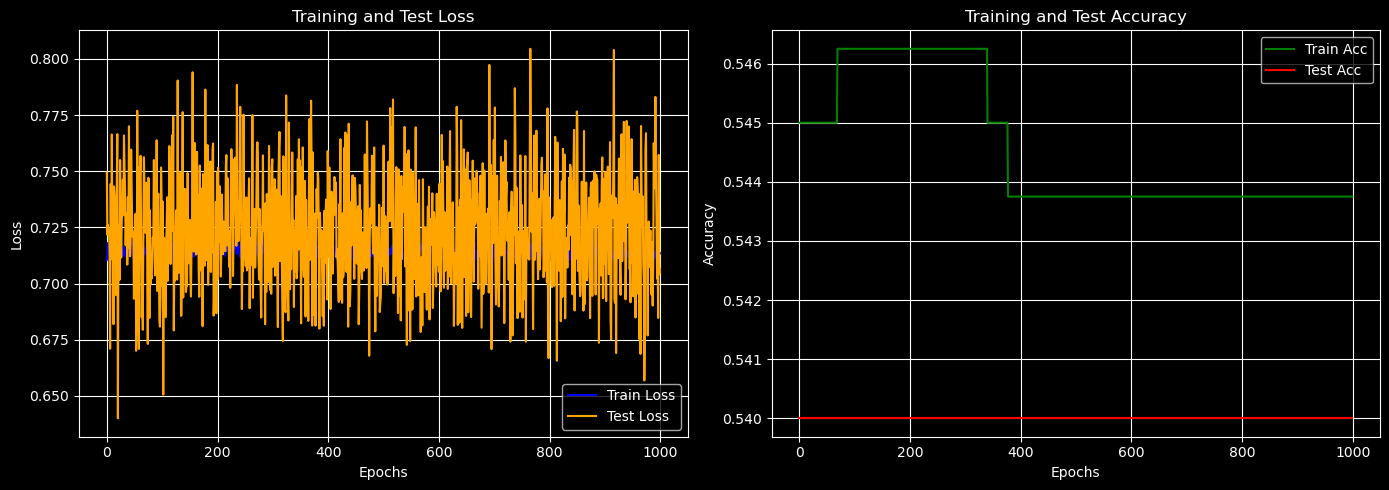

In [55]:
import matplotlib.pyplot as plt

# 创建画布，包含 1 行 2 列的子图
plt.figure(figsize=(14, 5))

# --- 第一个子图：Loss 曲线 ---
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='orange')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 第二个子图：Accuracy 曲线 ---
plt.subplot(1, 2, 2)
plt.plot(train_acc_arr, label='Train Acc', color='green')
plt.plot(test_acc_arr, label='Test Acc', color='red')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 自动调整布局，防止标题重叠
plt.tight_layout()
plt.show()

### Step 5: Visualization and Interpretation

Visualization tools like confusion matrices and ROC curves provide insights into the model's performance. The confusion matrix helps in understanding the classification accuracy, while the ROC curve illustrates the trade-off between sensitivity and specificity.

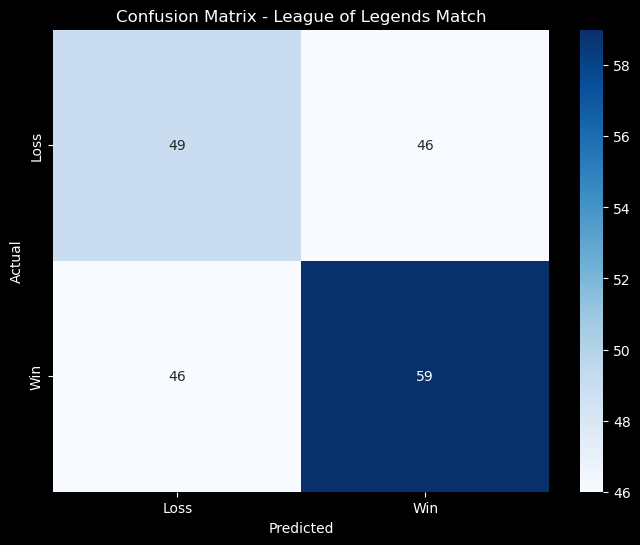

### Classification Report ###
              precision    recall  f1-score   support

        Loss       0.52      0.52      0.52        95
         Win       0.56      0.56      0.56       105

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.54      0.54       200



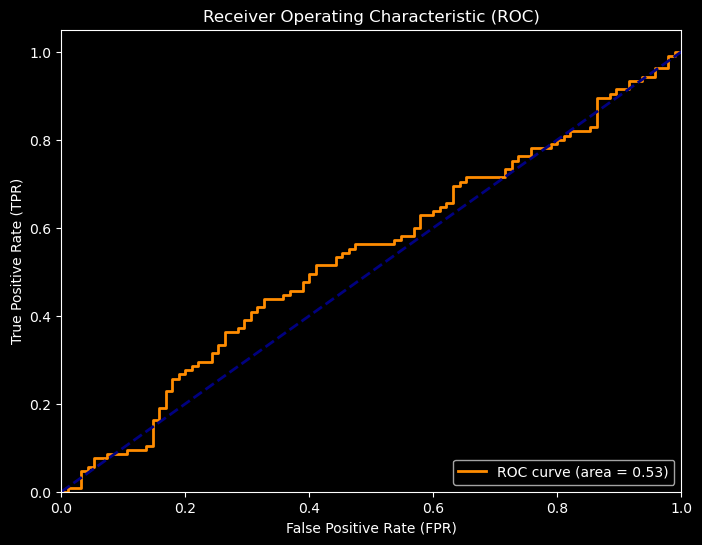

In [57]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs =[]

    with torch.no_grad():
        for x, y in dataloader:
            yhat = model(x)
            all_probs.extend(yhat.cpu().numpy())
            # 这里的逻辑必须和你计算 Accuracy 时保持一致
            # 如果模型里有 Sigmoid，用 > 0.5；如果没有，用 > 0
            predicted = (yhat > 0.5).float()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)

    # 可视化
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Loss', 'Win'],
                yticklabels=['Loss', 'Win'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix - League of Legends Match')
    plt.show()

    # 1. 打印分类报告 (Classification Report)
    # 这包含了 Precision, Recall, F1-score
    print("### Classification Report ###")
    print(classification_report(all_labels, all_preds, target_names=['Loss', 'Win']))

    # 2. 计算 ROC 曲线和 AUC
    # 注意：计算 ROC 通常需要模型的原始输出概率 (y_score)，即 sigmoid 后的值
    # 假设你在测试集中收集了概率值 all_probs
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # 3. 绘制 ROC 曲线
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 对角线
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

# 调用函数
plot_confusion_matrix(model, test_dataloader)

### Step 6: Model Saving and Loading

This task demonstrates the techniques to persist a trained model using torch.save and reload it using torch.load. Evaluating the loaded model ensures that it retains its performance, making it practical for deployment in real-world applications.



In [60]:
MODEL_PATH = './data/lol_logistic_regression.pt'
torch.save(model.state_dict(), MODEL_PATH)

In [61]:
loaded_model = LolLogisticRegressionModel(input_size=X_train_final.shape[1])
loaded_model.load_state_dict(torch.load(MODEL_PATH))

<All keys matched successfully>

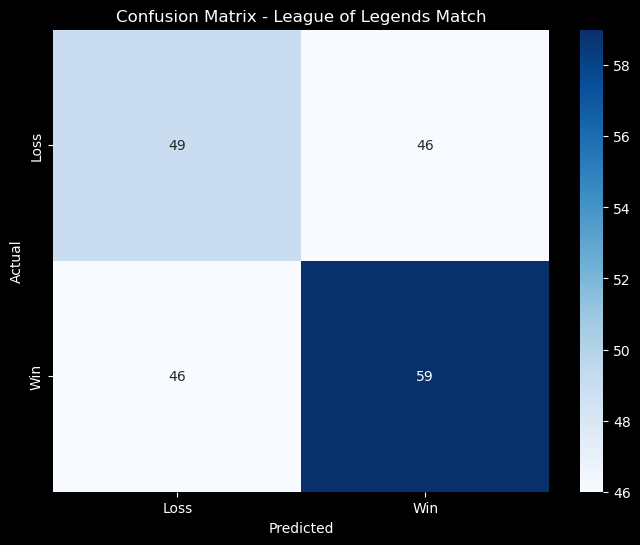

### Classification Report ###
              precision    recall  f1-score   support

        Loss       0.52      0.52      0.52        95
         Win       0.56      0.56      0.56       105

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.54      0.54       200



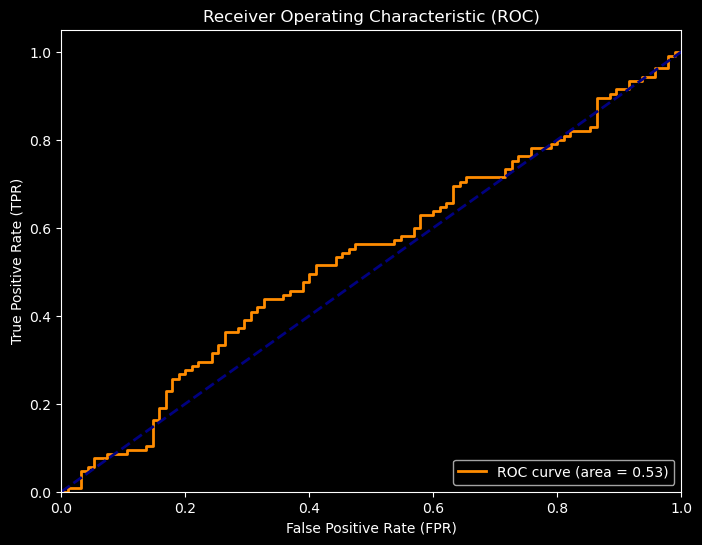

In [62]:
loaded_model.eval()
plot_confusion_matrix(loaded_model, test_dataloader)

### Step 7: Hyperparameter Tuning

By testing different learning rates, you will identify the optimal rate that provides the best test accuracy. This fine-tuning is crucial for enhancing model performance.

In [90]:
results = {} # 用于存储每个 lr 对应的最高测试准确率

for lr in [0.01, 0.05, 0.1]:
    print(f"开始测试学习率: {lr}")

    # --- 关键步骤：重新初始化 ---
    # 1. 重新实例化模型，清空权重
    model = LolLogisticRegressionModel(X_train_final.shape[1])
    # 2. 重新定义优化器，绑定当前 lr
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # --- 训练模型 ---
    # 假设你跑 50 个 Epoch
    train_losses, train_acc, test_losses, test_acc = train_lol_model(100, optimizer)

    # --- 记录结果 ---
    # 记录该学习率下达到的最大测试准确率
    best_acc = max(test_acc)
    results[lr] = best_acc
    print(f"学习率 {lr} 的最佳测试准确率: {best_acc:.4f}")

# --- 最终评估 ---
best_lr = max(results, key=results.get)
print(f"结论：表现最好的学习率是 {best_lr}，准确率为 {results[best_lr]:.4f}")

开始测试学习率: 0.01
train accuracy:  0.53125 test accuracy:  0.505
train accuracy:  0.53375 test accuracy:  0.505
train accuracy:  0.53625 test accuracy:  0.5
train accuracy:  0.53875 test accuracy:  0.5
train accuracy:  0.5425 test accuracy:  0.5
train accuracy:  0.54125 test accuracy:  0.5
train accuracy:  0.5425 test accuracy:  0.495
train accuracy:  0.5475 test accuracy:  0.495
train accuracy:  0.54875 test accuracy:  0.495
train accuracy:  0.55 test accuracy:  0.495
train accuracy:  0.54875 test accuracy:  0.495
train accuracy:  0.55125 test accuracy:  0.495
train accuracy:  0.55125 test accuracy:  0.5
train accuracy:  0.55625 test accuracy:  0.5
train accuracy:  0.5575 test accuracy:  0.5
train accuracy:  0.55375 test accuracy:  0.505
train accuracy:  0.55375 test accuracy:  0.52
train accuracy:  0.555 test accuracy:  0.525
train accuracy:  0.5525 test accuracy:  0.53
train accuracy:  0.55375 test accuracy:  0.545
train accuracy:  0.5525 test accuracy:  0.54
train accuracy:  0.5525 tes

In [91]:
results

{0.01: 0.545, 0.05: 0.52, 0.1: 0.53}

### Step 8: Feature Importance

Understanding feature importance helps in identifying which in-game statistics are most influential in predicting match outcomes. This step involves extracting the weights of the linear layer and visualizing them.

In [66]:
list(loaded_model.parameters())

[Parameter containing:
 tensor([[ 0.1056, -0.0930, -0.2367,  0.3151,  0.0593,  0.1641,  0.1960, -0.3372]],
        requires_grad=True),
 Parameter containing:
 tensor([0.0753], requires_grad=True)]

In [71]:
weights = loaded_model.linear.weight.data.numpy().flatten()
weights

array([ 0.10560909, -0.09301479, -0.23672667,  0.31510758,  0.05933402,
        0.16405949,  0.19602631, -0.33719572], dtype=float32)

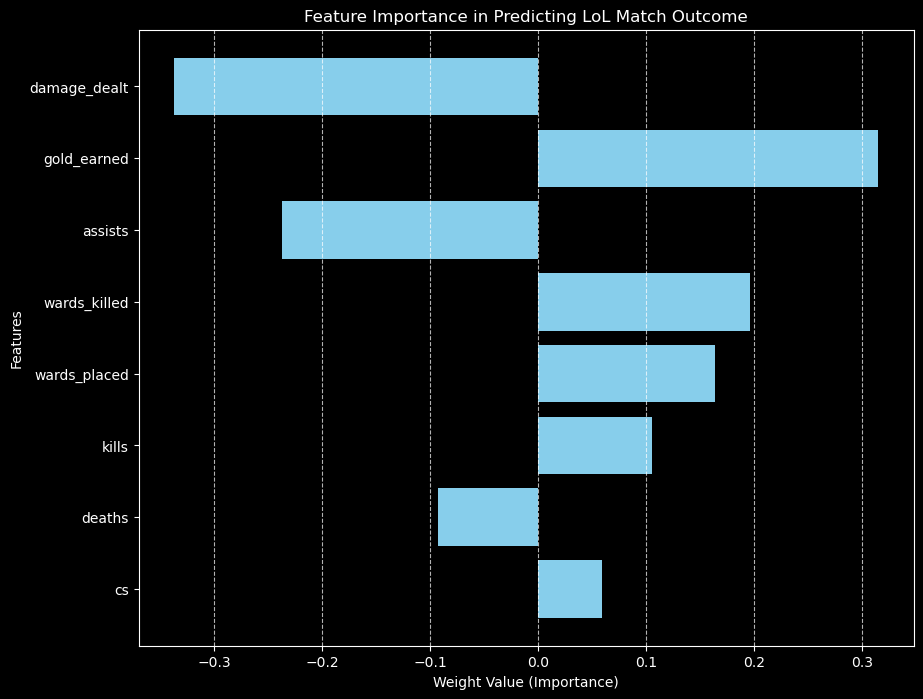

In [72]:
# 2. 创建 DataFrame 关联特征名
# 假设你的原始特征列名保存在 X_train.columns 中
feature_names = X.columns  # 或者你在预处理阶段定义的特征列表
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': weights
})

# 3. 按绝对值排序（因为负数大也代表重要，比如死亡数）
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=True)

# 4. 绘图
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Weight Value (Importance)')
plt.ylabel('Features')
plt.title('Feature Importance in Predicting LoL Match Outcome')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()